In [1]:
import sys 
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("src")

from data import load_prices, summary
from risk import (
    price_change,
    rolling_volatility,
    pnl,
    var,
    expected_shortfall,
    run_stress_test,
)
from trading import (
    position,
    signals,
    strategy_pnl,
    evaluate_strategy
)

file_path = "data/Day_ahead_prices.csv"
df = load_prices(file_path)
summary(df)
df.head()

,timestamp,price_eur_mwh
0,2021-09-01 00:00:00,94.78
1,2021-09-01 01:00:00,92.91
2,2021-09-01 02:00:00,91.21
3,2021-09-01 03:00:00,90.09
4,2021-09-01 04:00:00,93.12


In [2]:
df = price_change(df)

df["rolling_vol"] = rolling_volatility(df, window=24)

Q = 100
df["pnl"] = pnl(df["delta_p"], quantity=Q, direction="long")
var_95 = var(df["pnl"], confidence= 0.95)
var_99 = var(df["pnl"], confidence= 0.99)
es_95 = expected_shortfall(df["pnl"], confidence= 0.95)

print(f"VaR 95%: €{var_95:.2f}")
print(f"VaR 99%: €{var_99:.2f}")
print(f"ES 95%:  €{es_95:.2f}")

stress_table = run_stress_test(df["delta_p"], quantity=Q, direction= "long")
stress_table

# Implied price shocks for VaR levels
implied_shock_95 = -var_95 / Q
implied_shock_99 = -var_99 / Q

# Build the "Normal" and VaR rows in the same schema as run_stress_test's output
extra_rows = pd.DataFrame([
    {"scenario": "Normal",  "price_shock_eur": None,             "position_mwh": Q, "pnl_eur": 0.0},
    {"scenario": "95% VaR", "price_shock_eur": implied_shock_95, "position_mwh": Q, "pnl_eur": -var_95},
    {"scenario": "99% VaR", "price_shock_eur": implied_shock_99, "position_mwh": Q, "pnl_eur": -var_99},
])

full_stress_table = pd.concat([extra_rows, stress_table], ignore_index=True)

# Formatting
full_stress_table_display = full_stress_table.copy()
full_stress_table_display["price_shock_eur"] = full_stress_table_display["price_shock_eur"].map(
    lambda x: "—" if pd.isna(x) else f"{x:,.2f}"
)

full_stress_table_display["pnl_eur"] = full_stress_table_display["pnl_eur"].map(lambda x: f"{x:,.2f}")

full_stress_table_display

VaR 95%: €3234.80
VaR 99%: €6216.56
ES 95%:  €5281.04


,scenario,price_shock_eur,position_mwh,pnl_eur
0,Normal,—,100,0.00
1,95% VaR,-32.35,100,"-3,234.80"
2,99% VaR,-62.17,100,"-6,216.56"
3,-2sigma shock,-47.49,100,"-4,749.36"
4,-3sigma shock,-71.24,100,"-7,124.04"
5,-4sigma shock,-94.99,100,"-9,498.73"
6,worst historical move,-355.08,100,"-35,508.00"


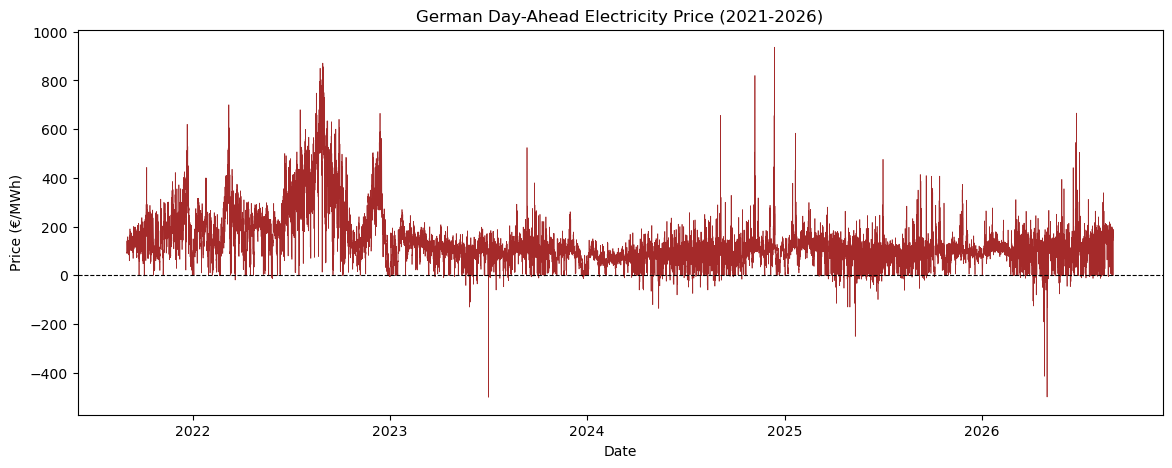

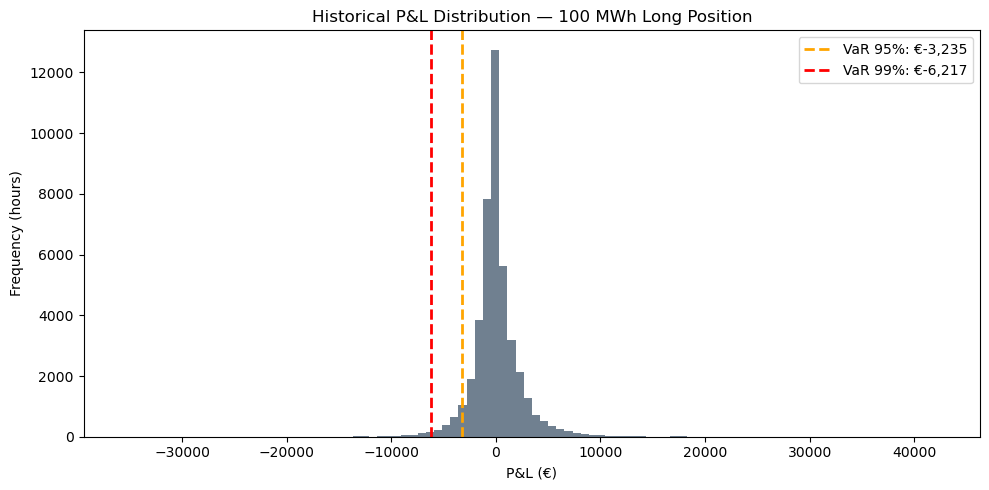

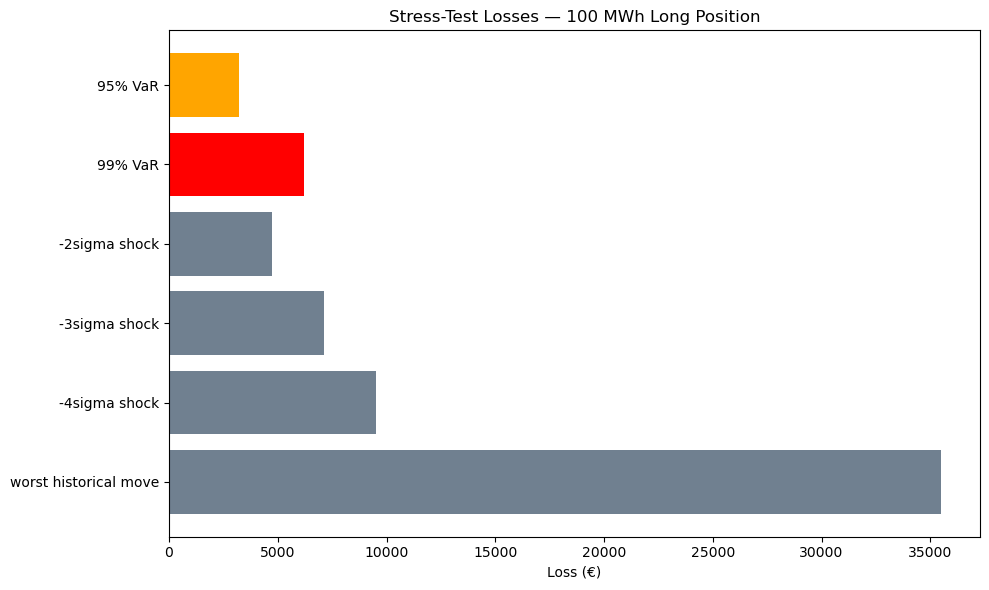

In [3]:
# Fig 1: Historical price
fig , ax = plt.subplots(figsize= (14,5) )
ax.plot(df["timestamp"], df["price_eur_mwh"], linewidth= 0.5, color= "brown")
ax.axhline(0, color = "black", linewidth = 0.8, linestyle = "--")
ax.set_title("German Day-Ahead Electricity Price (2021-2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (€/MWh)")
plt.tight_layout
plt.savefig("figures/electricity_price.pdf", dpi = 500)
plt.show()

# Fig 2: rolling volatility

fig, ax = plt.subplots(figsize= (10,5))
ax.hist(df["pnl"].dropna(), bins = 100, color = "slategray" , edgecolor = "none")

ax.axvline(-var_95, color="orange", linestyle="--", linewidth=2, label=f"VaR 95%: €{-var_95:,.0f}")
ax.axvline(-var_99, color="red", linestyle="--", linewidth=2, label=f"VaR 99%: €{-var_99:,.0f}")

ax.set_title("Historical P&L Distribution — 100 MWh Long Position")
ax.set_xlabel("P&L (€)")
ax.set_ylabel("Frequency (hours)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/pnl_distribution.pdf", dpi=150)
plt.show()

# Fig 3: Stress-test losses
scenarios = ["95% VaR", "99% VaR"] + stress_table["scenario"].tolist()
losses = [var_95, var_99] + (-stress_table["pnl_eur"]).tolist()  # flip sign to show as positive losses

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["orange", "red"] + ["slategray"] * len(stress_table)
ax.barh(scenarios, losses, color=colors)
ax.set_title("Stress-Test Losses — 100 MWh Long Position")
ax.set_xlabel("Loss (€)")
ax.invert_yaxis()  # largest/first scenario on top
plt.tight_layout()
plt.savefig("figures/risk_stress_test.pdf", dpi=150)
plt.show()

